№2 (5 баллов)
Скачайте файл с данными о публикациях на сайте Хабрахабр
(https://cloud.mail.ru/public/3ViL/q5xSM1TH2). Выполните следующие действия:
1. Изучите датасет, попробуйте понять какой столбец за что отвечает.
2. Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с
помощью filter() и удалите drop-ом:
df.drop(
 filter(lambda c: c.endswith("_lognorm"), df.columns),
 axis=1, # axis = 1: столбцы
 inplace=True,
) # избавляет от необходимости сохранять датасет
3. Столбец published (время публикации) содержит строки. Чтобы работать с этими
данными как с датой/временем публикации, приведите их к типу datetime:
df["published"] = pd.to_datetime(df.published, yearfirst=True)
4. Создайте несколько столбцов на основе данных о времени публикации:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]
df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]
5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого
года) было больше всего публикаций.
6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели,
используя параметр hue.
7. Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения
про данный датасет:
 Больше всего просмотров набирают статьи, опубликованные в 12 часов дня
 У опубликованных в 10 утра постов больше всего комментариев
 Больше всего просмотров набирают статьи, опубликованные в 6 часов утра
 Максимальное число комментариев на гиктаймсе набрала статья,
опубликованная в 9 часов вечера
 На хабре дневные статьи комментируют чаще, чем вечерние
8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20
авторов чаще всего минусуют?
9. Используя Seaborn, сравните субботы и понедельники. Правда ли, что по субботам
авторы пишут в основном днём, а по понедельникам — в основном вечером?

C:\Users\Norrim\AppData\Local\Temp\ipykernel_331896\3912424976.py:6: DtypeWarning: Columns (6,7,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('howpop_train.csv', decimal=",")


    hour         views
0      0  17546.982349
1      1  17717.709114
2      2  17328.690581
3      3  18370.017972
4      4  20678.389091
5      5  17218.894242
6      6  21354.310115
7      7  19093.953408
8      8  16014.419048
9      9  16904.411249
10    10  16580.889909
11    11  16324.946944
12    12  16209.416141
13    13  15821.496825
14    14  15773.203785
15    15  14739.224017
16    16  16582.675323
17    17  15814.881313
18    18  16731.210843
19    19  16926.284287
20    20  18134.614873
21    21  17605.819064
22    22  18365.387460
23    23  17631.345932


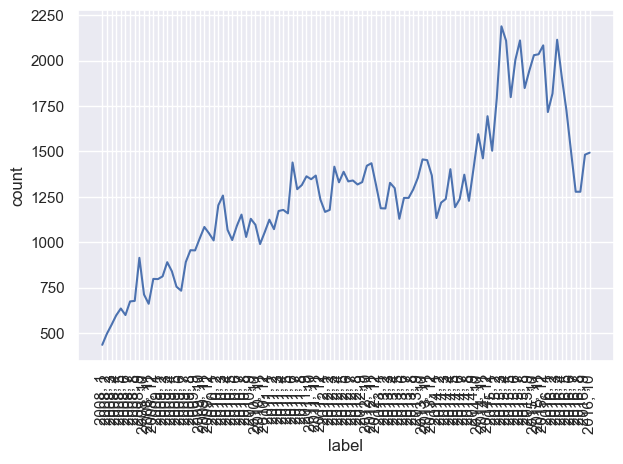

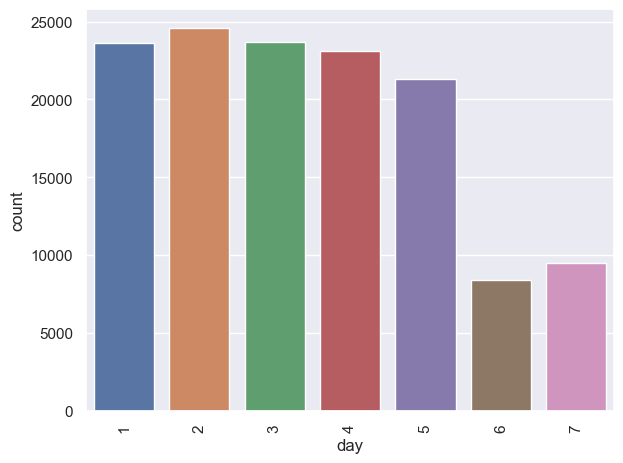

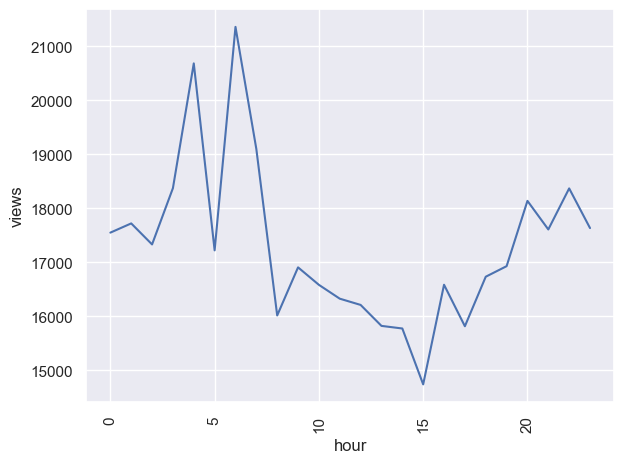

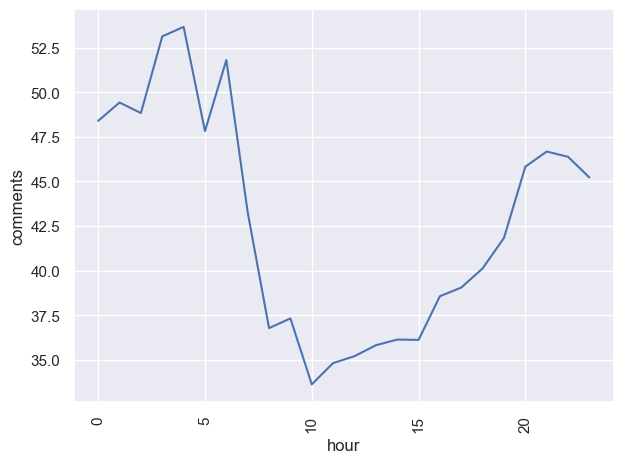

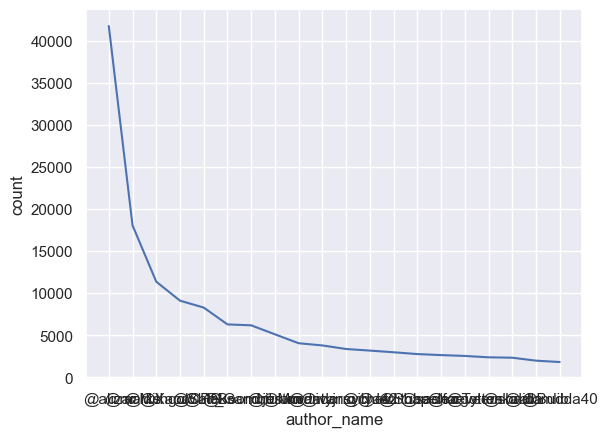

In [ ]:
import pandas as pd
import seaborn as sb
from matplotlib import pyplot as plt


df = pd.read_csv('howpop_train.csv', decimal=",")

print("2 Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с помощью filter() и удалите drop-ом:")
df.drop(
    filter(lambda c: c.endswith("_lognorm") or c.startswith("Unnamed"), df.columns),
    axis=1,
    inplace=True,
) 

print("3. Столбец published (время публикации) содержит строки. Чтобы работать с этими данными как с датой/временем публикации, приведите их к типу datetime:df[published] = pd.to_datetime(df.published, yearfirst=True)")
df["published"] = pd.to_datetime(df.published, yearfirst=True)

print("4. Создайте несколько столбцов на основе данных о времени публикации:")
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]
df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]

print("5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого года) было больше всего публикаций.")
yearm = df.groupby(['year', 'month']).size().reset_index(name='count')
yearm['label'] = yearm['year'].astype(str) + ', ' + yearm['month'].astype(str)
yearm = yearm.sort_values(['year', 'month']).reset_index(drop=True)

print("6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели,используя параметр hue.")
dayofw = df.groupby('dayofweek').size().reset_index(name='count')
dayofw['day'] = dayofw['dayofweek'].astype(str)

mostwatchedh = df.groupby('hour', as_index=False)['views'].mean()
mostcommentedh = df.groupby('hour', as_index=False)['comments'].mean()

print(mostwatchedh)

print("7. Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения про данный датасет: ")
sb.set_theme()
sb.lineplot(data=yearm, x='label', y='count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("У опубликованных в 10 утра постов больше всего комментариев")
sb.set_theme()
sb.barplot(data=dayofw, x='day', y='count', hue='day')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

sb.set_theme()
sb.lineplot(data=mostwatchedh, x='hour', y='views')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
"""Больше всего просмотров набирают статьи, опубликованные в 12 часов дня = false
Больше всего просмотров набирают статьи, опубликованные в 6 часов утра = true"""

sb.set_theme()
sb.lineplot(data=mostcommentedh, x='hour', y='comments')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
"""У опубликованных в 10 утра постов больше всего комментариев = false"""
"""На хабре дневные статьи комментируют чаще, чем вечерние = false"""


print("8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20 авторов чаще всего минусуют?")
authors = df.groupby('author')['votes_minus'].sum().nlargest(20).reset_index(name='count')
authors['author_name'] = authors['author'].astype(str)
sb.set_theme()
sb.lineplot(data=authors, x='author_name', y='count')
plt.show()